In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

# Basic check
print(df.head())
print(df.info())
print(df['target'].value_counts())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

# Feature **engineering**

In [19]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,55,100], labels=[0,1,2])
# thre groups young, middle , old

In [20]:
df['high_chol'] = (df['chol'] > 240).astype(int)
# binary classification on the basis of medical science

In [21]:
df['stress_index'] = df['oldpeak'] * df['thalach']

In [22]:
df['age_chol'] = df['age'] * df['chol']
#captures combined risk

In [24]:
# 1. Class distribution (percentage)
print(df['target'].value_counts(normalize=True))

# 2. Missing values
print(df.isnull().sum())

# 3. Statistical summary
print(df.describe())

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64
age             0
sex             0
cp              0
trestbps        0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
thal            0
target          0
age_group       0
high_chol       0
stress_index    0
age_chol        0
dtype: int64
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scale the Data for Logistic Regression

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86       100
           1       0.84      0.92      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



Recall = TP / (TP + FN), as it is more important, we work to improve it

predict_proba, return all the probabilities for class 0 or class 1, now we go to capture only the prob 1.

# **Threshold Hypertuning**

In [29]:
y_probs = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report

for t in [0.3, 0.4, 0.5, 0.6]:
    print(f"\nThreshold: {t}")

    y_pred = (y_probs >= t).astype(int) #astype() convert boolean to integer

    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.63      0.74       100
           1       0.73      0.93      0.82       105

    accuracy                           0.79       205
   macro avg       0.81      0.78      0.78       205
weighted avg       0.81      0.79      0.78       205


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       100
           1       0.84      0.92      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87   

Recall increases as we decrease the threshold very necessary to avoid false negatives.

# **Decision tree**
A Decision Tree is basically a sequence of if-else rules. with the goal to split them into pure groups by the end of the tree. We choose split on the basis of impurity reduction, either classification or regression.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



In [31]:
import pandas as pd

importance = dt.feature_importances_ #give which features were used more often
features = X.columns

feat_imp = pd.Series(importance, index=features) #map both name and the value given
print(feat_imp.sort_values(ascending=False))

cp              0.433632
ca              0.123055
thal            0.102780
age             0.090809
chol            0.061277
sex             0.053606
exang           0.039734
trestbps        0.031024
oldpeak         0.030394
stress_index    0.028509
age_chol        0.005180
fbs             0.000000
restecg         0.000000
thalach         0.000000
slope           0.000000
high_chol       0.000000
age_group       0.000000
dtype: float64


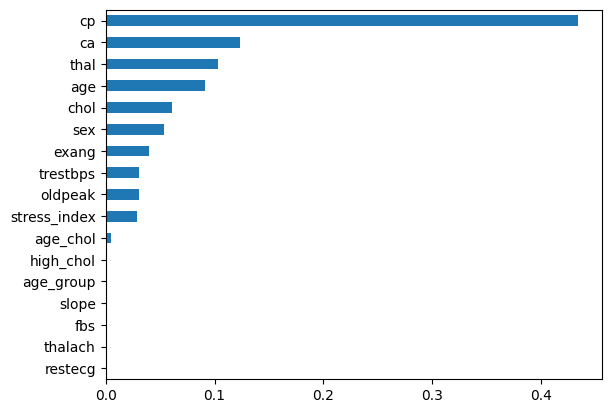

In [32]:
import matplotlib.pyplot as plt

feat_imp.sort_values().plot(kind='barh')
plt.show()

# **Random forest**
Instead of one tree, refer to many of them for better results and take decision on the basis of the majority.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200, #no. of trees
    max_depth=4, #depth limit of each tree
    min_samples_split=5, # min sample required for a split, aisa na ho ek ke basis pe leaf node bana di, also another function of min_sample_leaf, to check if this leaf will be considered in final decision
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       100
           1       0.87      0.95      0.91       105

    accuracy                           0.90       205
   macro avg       0.91      0.90      0.90       205
weighted avg       0.91      0.90      0.90       205



Using Grid Search to get best parameter

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',   # important for healthcare
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [35]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93       100
           1       0.91      0.97      0.94       105

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



In [36]:
from sklearn.metrics import confusion_matrix

#[[TN  FP]
#[FN  TP]]

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 90  10]
 [  3 102]]


In [37]:
from sklearn.metrics import roc_auc_score

y_probs = best_rf.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

ROC-AUC: 0.9821904761904763


# **Insights**

In [38]:
import pandas as pd

feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
print(feat_imp.sort_values(ascending=False))

cp              0.185700
thal            0.143662
ca              0.111656
oldpeak         0.082719
thalach         0.079388
exang           0.075485
stress_index    0.063764
age             0.052141
trestbps        0.039832
age_chol        0.038495
slope           0.034128
chol            0.033915
sex             0.023586
age_group       0.019601
restecg         0.006459
high_chol       0.006122
fbs             0.003348
dtype: float64


In [39]:
import joblib
joblib.dump(best_rf, "model.pkl")

['model.pkl']